## Predicting pH Levels in Georgia Water Systems Using Machine Learning

**With Adiva Parisa, Monisha Majumder**

## Data Conversion

In [1]:
import scipy.io
import pandas as pd
import numpy as np

In [2]:
mat = scipy.io.loadmat("water_dataset.mat")

mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X_tr', 'X_te', 'Y_tr', 'Y_te', 'location_group', 'features', 'location_ids'])

In [3]:
feature_names = []

for x in mat["features"][0]:
    feature_names.append(x.item())

feature_names

['Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Maximum)',
 'pH, water, unfiltered, field, standard units (Maximum)',
 'pH, water, unfiltered, field, standard units (Minimum)',
 'Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Minimum)',
 'Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Mean)',
 'Dissolved oxygen, water, unfiltered, milligrams per liter (Maximum)',
 'Dissolved oxygen, water, unfiltered, milligrams per liter (Mean)',
 'Dissolved oxygen, water, unfiltered, milligrams per liter (Minimum)',
 'Temperature, water, degrees Celsius (Mean)',
 'Temperature, water, degrees Celsius (Minimum)',
 'Temperature, water, degrees Celsius (Maximum)']

In [4]:
feature_names = [
    "conductance_max",
    "ph_max",
    "ph_min",
    "conductance_min",
    "conductance_mean",
    "oxygen_max",
    "oxygen_mean",
    "oxygen_min",
    "temperature_mean",
    "temperature_min",
    "temperature_max"
]

In [5]:
X_cells = mat["X_tr"][0]

X_list = []

for day, daily_matrix in enumerate(X_cells):
    
    daily_df = pd.DataFrame(
        daily_matrix,
        columns=feature_names
    )
    
    daily_df["day"] = day
    daily_df["location"] = np.arange(37)
    
    X_list.append(daily_df)


X_train_df = pd.concat(
    X_list,
    ignore_index=True
)

In [6]:
X_train_df.shape

(15651, 13)

In [7]:
Y_train = mat["Y_tr"]

y_list = []

for day in range(Y_train.shape[1]):
    for location in range(Y_train.shape[0]):
        
        y_list.append(
            Y_train[location, day]
        )


y_train = pd.Series(
    y_list,
    name="pH"
)

In [8]:
y_train.shape

(15651,)

In [9]:
df = X_train_df.copy()

df["pH"] = y_train

df.head()

,conductance_max,ph_max,ph_min,conductance_min,conductance_mean,oxygen_max,oxygen_mean,oxygen_min,temperature_mean,temperature_min,temperature_max,day,location,pH
0,0.001131,0.884615,0.001120,0.001113,0.677632,0.841463,0.765152,0.787402,0.293750,0.298077,0.276163,0,0,0.648148
1,0.001170,0.871795,0.001159,0.001152,0.703947,0.829268,0.772727,0.795276,0.293750,0.301282,0.276163,0,1,0.648148
2,0.001326,0.884615,0.001198,0.001250,0.677632,0.853659,0.750000,0.755906,0.300000,0.298077,0.287791,0,2,0.648148
3,0.014094,0.858974,0.001238,0.003926,0.697368,0.829268,0.772727,0.771654,0.296875,0.294872,0.279070,0,3,0.638889
4,0.088109,0.858974,0.010766,0.029297,0.684211,0.853659,0.765152,0.755906,0.296875,0.291667,0.281977,0,4,0.648148


In [10]:
df.shape

(15651, 14)

In [11]:
df.dtypes

conductance_max     float64
ph_max              float64
ph_min              float64
conductance_min     float64
conductance_mean    float64
oxygen_max          float64
oxygen_mean         float64
oxygen_min          float64
temperature_mean    float64
temperature_min     float64
temperature_max     float64
day                   int64
location              int64
pH                  float64
dtype: object

In [12]:
df.isna().sum()

conductance_max     0
ph_max              0
ph_min              0
conductance_min     0
conductance_mean    0
oxygen_max          0
oxygen_mean         0
oxygen_min          0
temperature_mean    0
temperature_min     0
temperature_max     0
day                 0
location            0
pH                  0
dtype: int64

## Exploratory Data Analysis

In [13]:
# dataset summary
df.describe()

,conductance_max,ph_max,ph_min,conductance_min,conductance_mean,oxygen_max,oxygen_mean,oxygen_min,temperature_mean,temperature_min,temperature_max,day,location,pH
count,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000
mean,0.065207,0.889402,0.028976,0.043222,0.567845,0.858595,0.604889,0.578301,0.557072,0.536780,0.553200,211.000000,18.000000,0.664371
std,0.161383,0.034803,0.120825,0.133254,0.120533,0.031062,0.146772,0.171843,0.204049,0.212293,0.190127,122.113142,10.677419,0.029318
min,0.000526,0.576923,0.000334,0.000508,0.125000,0.719512,0.075758,0.031496,0.059375,0.025641,0.090116,0.000000,0.000000,0.574074
25%,0.001891,0.871795,0.001631,0.001777,0.486842,0.841463,0.515152,0.480315,0.393750,0.365385,0.398256,105.000000,9.000000,0.648148
50%,0.002632,0.897436,0.002220,0.002441,0.565789,0.853659,0.606061,0.590551,0.531250,0.509615,0.531977,211.000000,18.000000,0.666667
75%,0.005458,0.910256,0.003536,0.004824,0.657895,0.878049,0.712121,0.708661,0.740625,0.724359,0.723837,317.000000,27.000000,0.675926
max,1.000000,0.987179,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,422.000000,36.000000,0.962963


In [14]:
df["pH"].describe()

count    15651.000000
mean         0.664371
std          0.029318
min          0.574074
25%          0.648148
50%          0.666667
75%          0.675926
max          0.962963
Name: pH, dtype: float64

The target variable represents the median pH measurement provided in the dataset. The values range from approximately 0.57 to 0.96, indicating that the pH values have been normalized in the provided MATLAB dataset rather than being stored on the traditional 0–14 pH scale. Since all observations use the same transformation, the normalized values can still be used for regression modeling and performance evaluation.

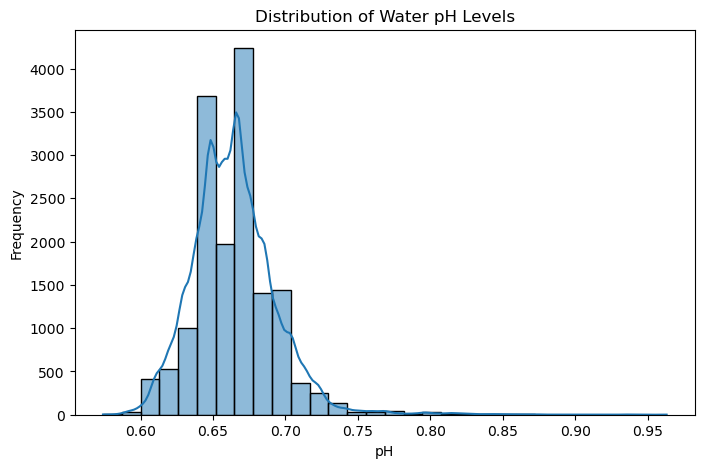

In [15]:
# analyze target variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df["pH"],
    bins=30,
    kde=True
)

plt.title("Distribution of Water pH Levels")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.show()

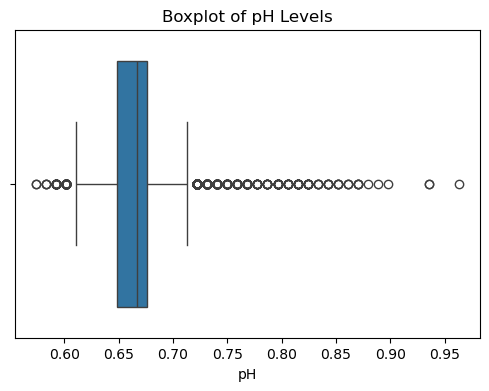

In [16]:
# boxplot for outliers
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df["pH"]
)

plt.title("Boxplot of pH Levels")

plt.show()

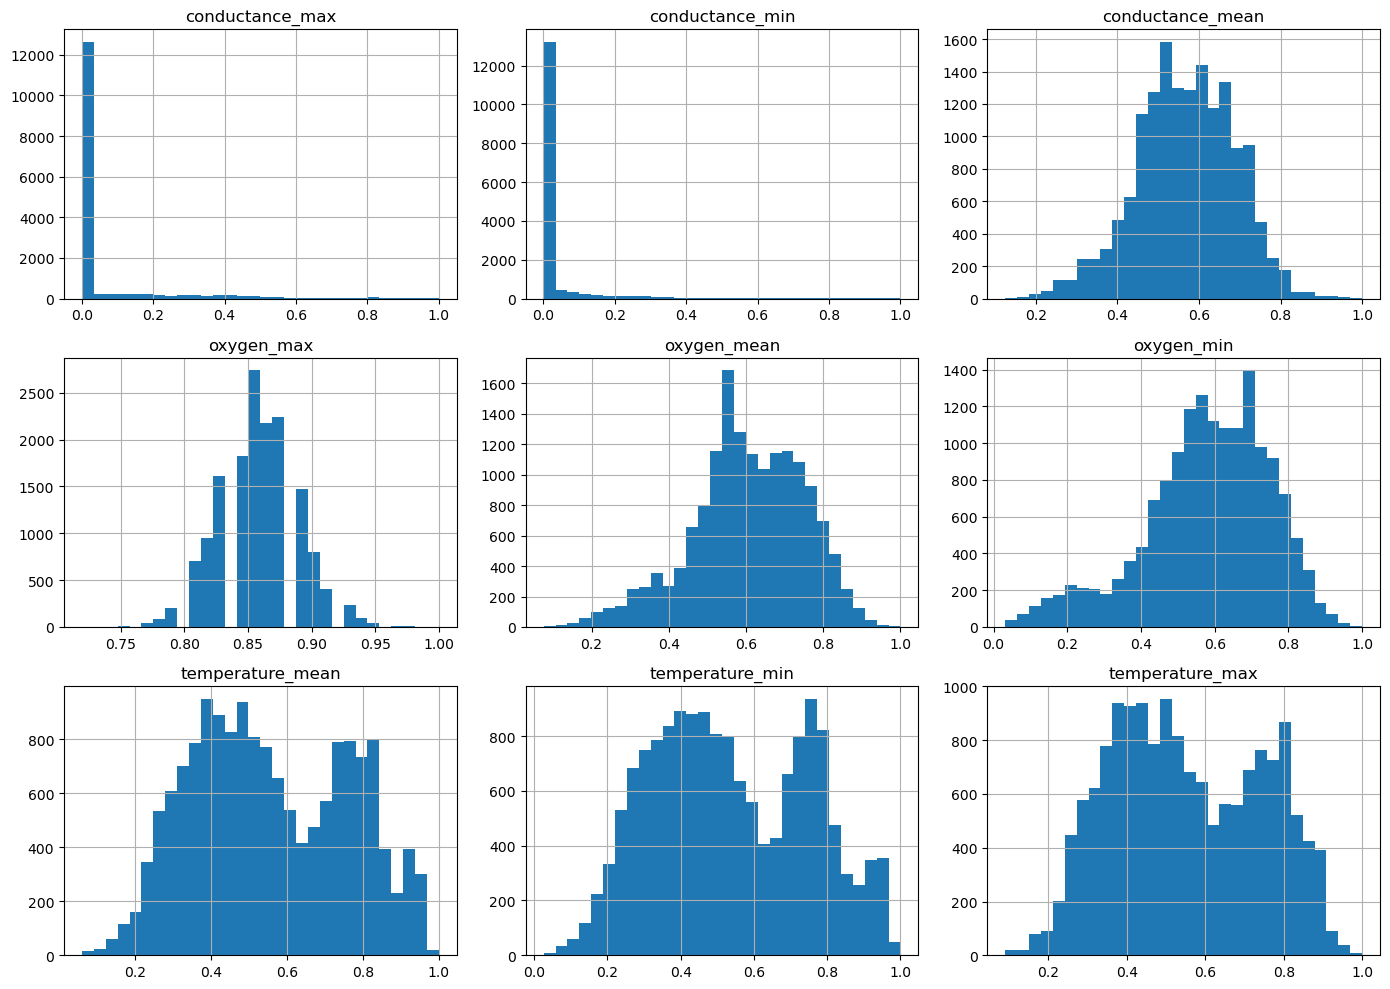

In [17]:
# feature distribution
features = [
    "conductance_max",
    "conductance_min",
    "conductance_mean",
    "oxygen_max",
    "oxygen_mean",
    "oxygen_min",
    "temperature_mean",
    "temperature_min",
    "temperature_max"
]

df[features].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()
plt.show()

I left out ph_max and ph_min because they are directly related to pH and will dominate some plots.

In [18]:
# correlation analysis
correlations = (
    df.corr(numeric_only=True)["pH"]
    .sort_values(ascending=False)
)

correlations

pH                  1.000000
oxygen_max          0.877174
ph_max              0.721502
conductance_max     0.298815
conductance_min     0.298015
ph_min              0.267316
conductance_mean    0.170184
location            0.128045
day                 0.123410
oxygen_mean         0.044419
temperature_max     0.034137
temperature_mean    0.018192
temperature_min     0.004858
oxygen_min         -0.027017
Name: pH, dtype: float64

Higher maximum dissolved oxygen levels are strongly associated with higher pH values. This suggests dissolved oxygen may be an important factor for predicting water acidity/alkalinity conditions. 
The strong correlation between pH maximum and median pH is expected because both variables measure the same chemical property. However, pH maximum represents a separate measurement statistic available from the dataset.
Specific conductance shows a moderate positive relationship with pH, suggesting dissolved ions and conductivity levels may provide additional information for predicting pH.
Temperature measurements show little linear relationship with pH in this dataset, suggesting temperature alone may not be a strong predictor.
The maximum dissolved oxygen is much more informative than the average or minimum. This could indicate that peak oxygen conditions are more associated with pH changes.

The correlation analysis shows that dissolved oxygen maximum has the strongest relationship with pH (r = 0.877), indicating that oxygen levels may be an important predictor of water acidity. The maximum pH measurement also has a strong correlation with the target median pH (r = 0.722), which is expected because both variables represent pH measurements collected using different daily summary statistics. Specific conductance features show moderate positive correlations with pH, while temperature measurements show little linear association. These findings suggest that dissolved oxygen and conductance variables may contribute most to predictive performance.

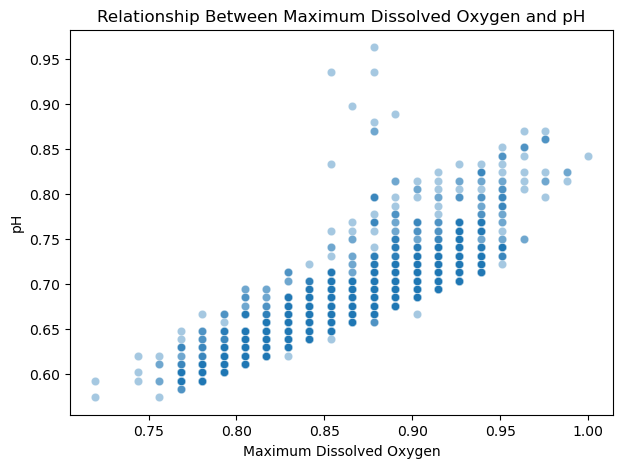

In [19]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="oxygen_max",
    y="pH",
    alpha=0.4
)

plt.title("Relationship Between Maximum Dissolved Oxygen and pH")
plt.xlabel("Maximum Dissolved Oxygen")
plt.ylabel("pH")

plt.show()

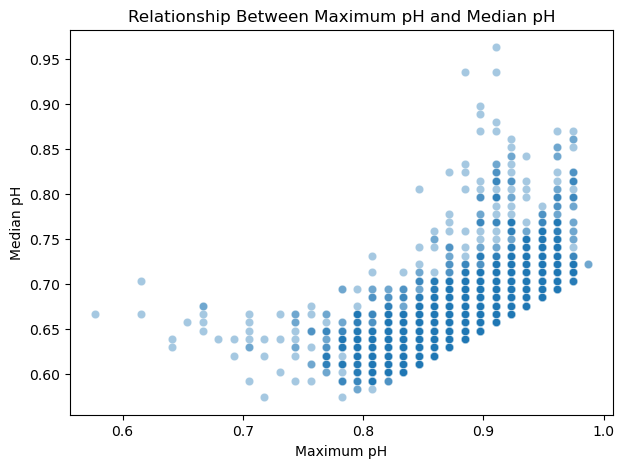

In [20]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="ph_max",
    y="pH",
    alpha=0.4
)

plt.title("Relationship Between Maximum pH and Median pH")
plt.xlabel("Maximum pH")
plt.ylabel("Median pH")

plt.show()

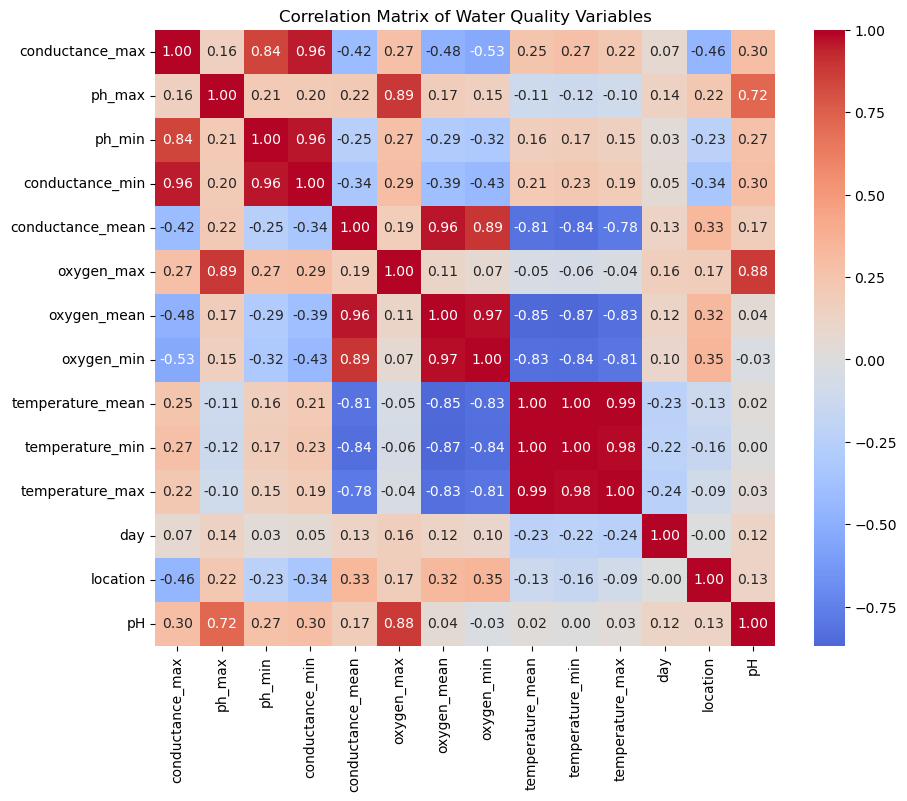

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Water Quality Variables")

plt.show()

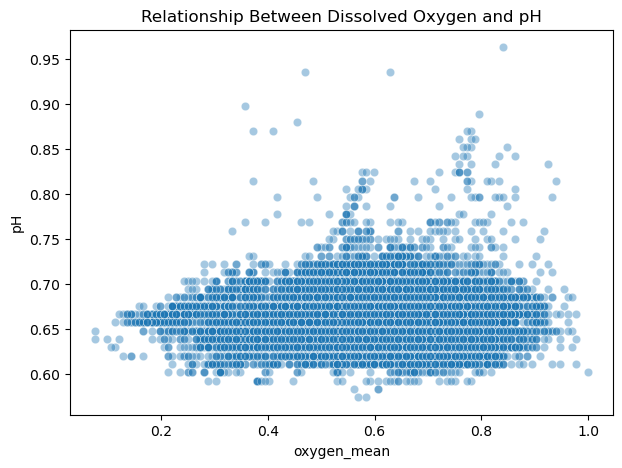

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="oxygen_mean",
    y="pH",
    alpha=0.4
)

plt.title("Relationship Between Dissolved Oxygen and pH")

plt.show()

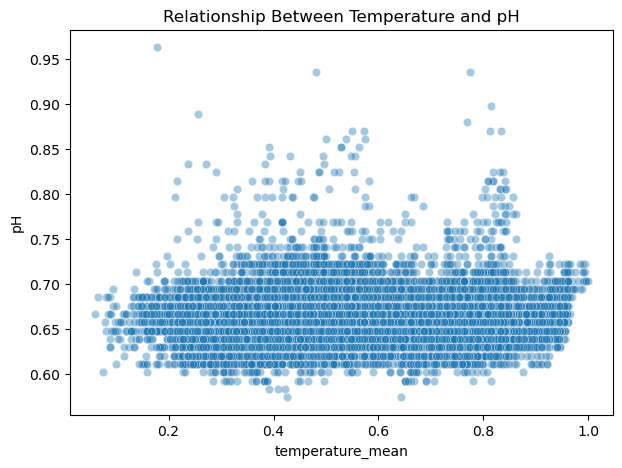

In [23]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="temperature_mean",
    y="pH",
    alpha=0.4
)

plt.title("Relationship Between Temperature and pH")

plt.show()

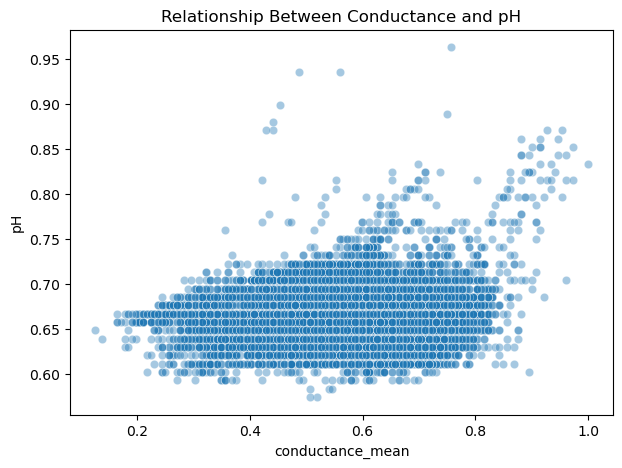

In [24]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="conductance_mean",
    y="pH",
    alpha=0.4
)

plt.title("Relationship Between Conductance and pH")

plt.show()

In [25]:
# location analysis
location_pH = (
    df.groupby("location")["pH"]
    .mean()
    .sort_values()
)

location_pH

location
22    0.622187
24    0.631074
9     0.638670
19    0.639896
14    0.640443
16    0.647491
29    0.648323
13    0.649068
0     0.649221
6     0.650819
10    0.651038
5     0.652701
36    0.652767
21    0.653511
12    0.655284
35    0.656379
20    0.659618
2     0.661194
25    0.663580
18    0.663690
11    0.664456
15    0.664719
1     0.666032
33    0.666098
3     0.673518
30    0.675992
23    0.676145
26    0.676823
17    0.677480
27    0.678925
4     0.680676
34    0.683149
7     0.687987
31    0.689169
28    0.693481
8     0.708169
32    0.731941
Name: pH, dtype: float64

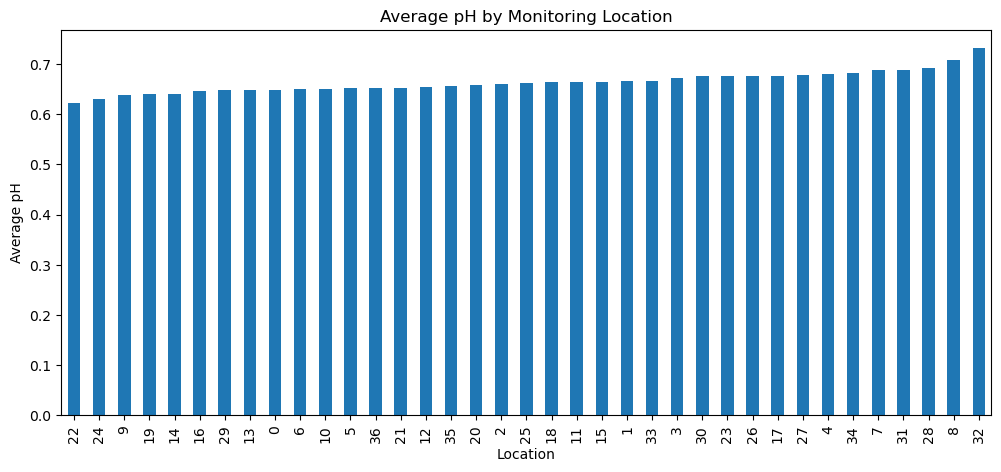

In [26]:
plt.figure(figsize=(12,5))

location_pH.plot(
    kind="bar"
)

plt.title("Average pH by Monitoring Location")
plt.xlabel("Location")
plt.ylabel("Average pH")

plt.show()

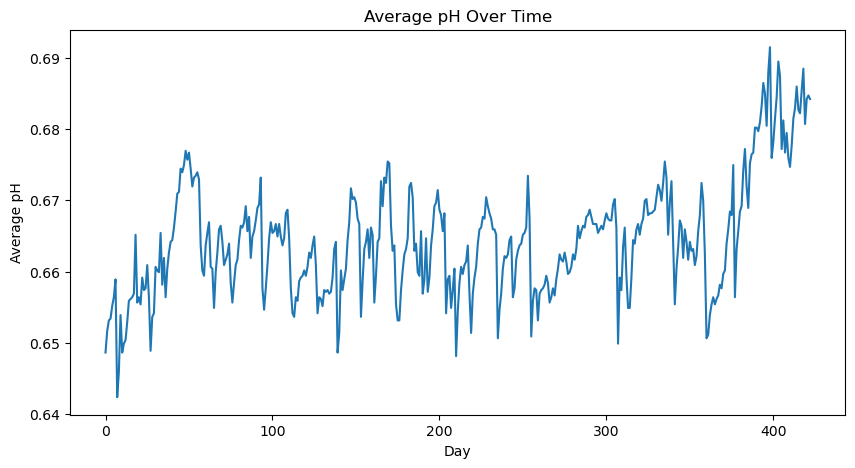

In [27]:
daily_pH = (
    df.groupby("day")["pH"]
    .mean()
)

plt.figure(figsize=(10,5))

daily_pH.plot()

plt.title("Average pH Over Time")
plt.xlabel("Day")
plt.ylabel("Average pH")

plt.show()

## Creating Modeling Dataset

The dataset contains daily pH summary measurements (maximum and minimum pH) in addition to the target median pH. Since the objective is to predict pH using other water quality indicators, the pH maximum and minimum features were excluded to prevent information leakage and ensure the model relies on independent water quality measurements.

In [28]:
# Features: water quality measurements only
X = df.drop(
    columns=[
        "pH",
        "ph_max",
        "ph_min",
        "day",
        "location"
    ]
)

# Target
y = df["pH"]


print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15651, 9)
Target shape: (15651,)


In [29]:
df["day"].min(), df["day"].max()

(0, 422)

In [30]:
split_day = int(df["day"].max() * 0.8)

split_day

337

In [31]:
train_df = df[df["day"] <= split_day]

test_df = df[df["day"] > split_day]


print("Training days:", train_df["day"].min(), "-", train_df["day"].max())
print("Testing days:", test_df["day"].min(), "-", test_df["day"].max())

print("\nTraining size:", train_df.shape)
print("Testing size:", test_df.shape)

Training days: 0 - 337
Testing days: 338 - 422

Training size: (12506, 14)
Testing size: (3145, 14)


In [32]:
X_train = train_df.drop(
    columns=[
        "pH",
        "ph_max",
        "ph_min",
        "day",
        "location"
    ]
)

y_train = train_df["pH"]

In [33]:
X_test = test_df.drop(
    columns=[
        "pH",
        "ph_max",
        "ph_min",
        "day",
        "location"
    ]
)

y_test = test_df["pH"]

In [34]:
print(X_train.shape)
print(X_test.shape)

(12506, 9)
(3145, 9)


## Model Building and Evaluation

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np
import pandas as pd

In [36]:
def evaluate_model(model_name, y_true, y_pred):
    
    return pd.DataFrame({
        "Model": [model_name],
        "R²": [r2_score(y_true, y_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
        "MAE": [mean_absolute_error(y_true, y_pred)]
    })

In [37]:
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)


baseline_results = evaluate_model(
    "Mean Baseline",
    y_test,
    baseline_prediction
)

baseline_results

,Model,R²,RMSE,MAE
0,Mean Baseline,-0.076872,0.033426,0.024578


In [38]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)


lr_pred = lr.predict(X_test)


lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

lr_results

,Model,R²,RMSE,MAE
0,Linear Regression,0.832,0.013203,0.008276


In [39]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)


rf_pred = rf.predict(X_test)


rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_results

,Model,R²,RMSE,MAE
0,Random Forest,0.788495,0.014814,0.00852


In [40]:
gb = GradientBoostingRegressor(
    random_state=42
)


gb.fit(
    X_train,
    y_train
)


gb_pred = gb.predict(X_test)


gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

gb_results

,Model,R²,RMSE,MAE
0,Gradient Boosting,0.84166,0.012817,0.008237


In [41]:
model_results = pd.concat(
    [
        baseline_results,
        lr_results,
        rf_results,
        gb_results
    ],
    ignore_index=True
)


model_results.sort_values(
    by="R²",
    ascending=False
)

,Model,R²,RMSE,MAE
3,Gradient Boosting,0.841660,0.012817,0.008237
1,Linear Regression,0.832000,0.013203,0.008276
2,Random Forest,0.788495,0.014814,0.008520
0,Mean Baseline,-0.076872,0.033426,0.024578


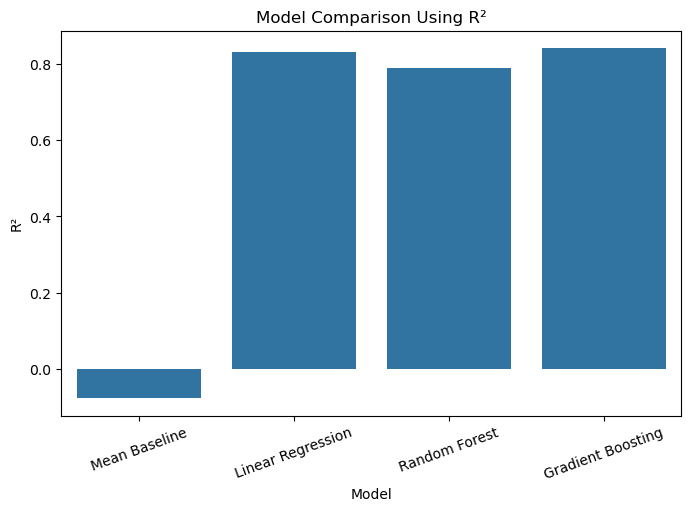

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))


sns.barplot(
    data=model_results,
    x="Model",
    y="R²"
)


plt.title("Model Comparison Using R²")
plt.ylabel("R²")
plt.xticks(rotation=20)

plt.show()

## Feature Importance

In [43]:
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

gb_importance

,Feature,Importance
3,oxygen_max,0.891706
0,conductance_max,0.037141
2,conductance_mean,0.034932
8,temperature_max,0.015740
1,conductance_min,0.007291
4,oxygen_mean,0.004184
5,oxygen_min,0.003910
6,temperature_mean,0.003297
7,temperature_min,0.001799


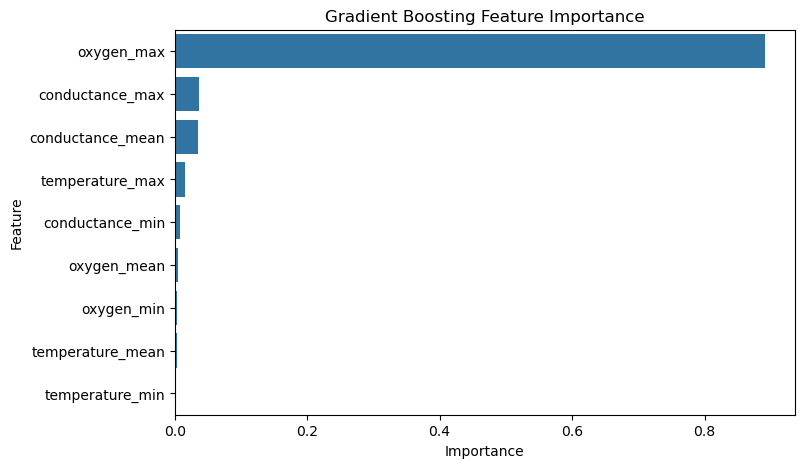

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=gb_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")

plt.show()

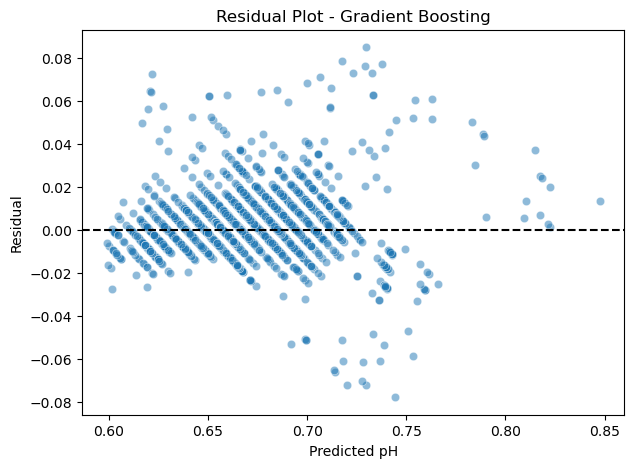

In [45]:
# Calculate residuals
gb_residuals = y_test - gb_pred


plt.figure(figsize=(7,5))

sns.scatterplot(
    x=gb_pred,
    y=gb_residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Predicted pH")
plt.ylabel("Residual")

plt.title("Residual Plot - Gradient Boosting")

plt.show()

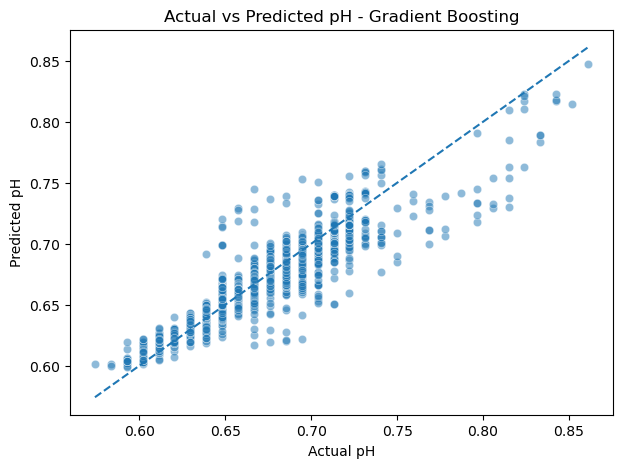

In [46]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=gb_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")

plt.title("Actual vs Predicted pH - Gradient Boosting")

plt.show()

## Location Test

In [47]:
X_location = df.drop(
    columns=[
        "pH",
        "ph_max",
        "ph_min",
        "day"
    ]
)

y_location = df["pH"]


X_location.head()

,conductance_max,conductance_min,conductance_mean,oxygen_max,oxygen_mean,oxygen_min,temperature_mean,temperature_min,temperature_max,location
0,0.001131,0.001113,0.677632,0.841463,0.765152,0.787402,0.293750,0.298077,0.276163,0
1,0.001170,0.001152,0.703947,0.829268,0.772727,0.795276,0.293750,0.301282,0.276163,1
2,0.001326,0.001250,0.677632,0.853659,0.750000,0.755906,0.300000,0.298077,0.287791,2
3,0.014094,0.003926,0.697368,0.829268,0.772727,0.771654,0.296875,0.294872,0.279070,3
4,0.088109,0.029297,0.684211,0.853659,0.765152,0.755906,0.296875,0.291667,0.281977,4


In [48]:
train_location = df[df["day"] <= split_day]

test_location = df[df["day"] > split_day]

In [49]:
X_train_loc = train_location.drop(
    columns=[
        "pH",
        "ph_max",
        "ph_min",
        "day"
    ]
)

y_train_loc = train_location["pH"]


X_test_loc = test_location.drop(
    columns=[
        "pH",
        "ph_max",
        "ph_min",
        "day"
    ]
)

y_test_loc = test_location["pH"]

In [50]:
print(X_train_loc.shape)
print(X_test_loc.shape)

(12506, 10)
(3145, 10)


In [51]:
gb_location = GradientBoostingRegressor(
    random_state=42
)


gb_location.fit(
    X_train_loc,
    y_train_loc
)


gb_location_pred = gb_location.predict(
    X_test_loc
)

In [52]:
gb_location_results = evaluate_model(
    "Gradient Boosting + Location",
    y_test_loc,
    gb_location_pred
)


gb_location_results

,Model,R²,RMSE,MAE
0,Gradient Boosting + Location,0.833757,0.013133,0.008175


In [53]:
location_comparison = pd.concat(
    [
        gb_results,
        gb_location_results
    ],
    ignore_index=True
)


location_comparison

,Model,R²,RMSE,MAE
0,Gradient Boosting,0.841660,0.012817,0.008237
1,Gradient Boosting + Location,0.833757,0.013133,0.008175


Location provided limited additional predictive value, suggesting that measured water quality variables captured most of the variation in pH.

The addition of monitoring location as a feature did not improve Gradient Boosting performance. This suggests that the measured water quality variables, particularly dissolved oxygen and conductivity-related measurements, captured most of the variation in pH. While spatial differences exist between monitoring sites, location alone did not provide significant additional predictive information under the time-based evaluation.

Location was evaluated as an additional feature to account for possible spatial differences between monitoring sites. However, including location did not improve predictive performance, so the final model relied on water quality measurements only.

## Model Results Summary

Three regression models were evaluated using a time-based train/test split to simulate forecasting future water conditions. A mean baseline model was also included for comparison.

The Gradient Boosting Regressor achieved the best predictive performance with an R² score of 0.842, RMSE of 0.0128, and MAE of 0.0082. Linear Regression performed similarly, while Random Forest showed lower performance under the time-based evaluation. All machine learning models significantly outperformed the mean baseline, demonstrating that water quality measurements provide meaningful information for predicting future pH levels.

The lower performance compared to a random train/test split highlights the importance of evaluating water quality models using temporal validation. Random splits may produce overly optimistic results because measurements from similar locations and time periods can appear in both training and testing data.

## Feature Importance Analysis

Feature importance from the Gradient Boosting model was analyzed to identify which water quality measurements contributed most to pH prediction.

The most influential features were dissolved oxygen and specific conductance measurements. This finding agrees with the correlation analysis, where maximum dissolved oxygen showed the strongest relationship with pH.

These results suggest that changes in dissolved oxygen levels provide valuable information about future pH conditions. Other variables, including temperature measurements, contributed smaller amounts to prediction performance.

## Spatial Analysis Using Monitoring Location

Because the dataset contains measurements from multiple monitoring sites across Georgia, location was evaluated as an additional feature to determine whether spatial information improves prediction.

A Gradient Boosting model was trained with and without the location identifier. Including location slightly decreased performance, reducing R² from 0.842 to 0.834.

This suggests that the water quality measurements themselves capture most of the variation needed for predicting pH. Although differences exist between monitoring locations, the location identifier alone does not provide significant additional predictive value beyond the measured environmental variables.

## Final Conclusion

This project developed machine learning models to forecast pH levels in Georgia water systems using historical water quality measurements. The goal was to determine whether pH could be estimated using related environmental indicators such as dissolved oxygen, specific conductance, and temperature.

After evaluating multiple regression approaches, Gradient Boosting achieved the strongest performance under a time-based evaluation, with an R² of 0.842. This indicates that the model was able to explain a large portion of the variation in future pH values using only other water quality measurements.

Feature analysis showed that dissolved oxygen variables were the strongest predictors of pH, highlighting the connection between oxygen conditions and water chemistry. Additionally, monitoring location was tested as a spatial feature but did not improve prediction accuracy, suggesting that the measured water quality variables were more informative than location alone.

Overall, the results demonstrate that machine learning can support water quality monitoring by estimating future pH conditions and identifying important relationships among environmental measurements.

## Limitations

Several limitations should be considered when interpreting the results.

First, the dataset contains measurements from monitoring locations only within Georgia, meaning the model may not generalize to other regions with different environmental conditions.

Second, the dataset represents a specific historical period. Changes in climate, land use, pollution sources, or water management practices could affect future model performance.

Third, although a time-based split was used to better represent forecasting conditions, the model does not explicitly model temporal dependencies between consecutive days or spatial relationships between connected water systems. Future work could explore time-series approaches such as recurrent neural networks or spatio-temporal models.

Finally, the dataset is relatively small compared with many machine learning applications, which limits the complexity of models that can be reliably trained without overfitting.